In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('ACDC_radiomics.csv')

In [4]:
df.head()

,original_shape_Elongation_LV_ED,original_shape_Flatness_LV_ED,original_shape_LeastAxisLength_LV_ED,original_shape_MajorAxisLength_LV_ED,original_shape_Maximum2DDiameterColumn_LV_ED,original_shape_Maximum2DDiameterRow_LV_ED,original_shape_Maximum2DDiameterSlice_LV_ED,original_shape_Maximum3DDiameter_LV_ED,original_shape_MeshVolume_LV_ED,original_shape_MinorAxisLength_LV_ED,...,original_glszm_ZonePercentage_MYO_ES,original_glszm_ZoneVariance_MYO_ES,original_ngtdm_Busyness_MYO_ES,original_ngtdm_Coarseness_MYO_ES,original_ngtdm_Complexity_MYO_ES,original_ngtdm_Contrast_MYO_ES,original_ngtdm_Strength_MYO_ES,height,weight,class
0,0.560917,0.110560,6.592758,59.630582,45.398238,64.776539,64.007812,65.199693,5674.000000,33.447817,...,0.053567,40384.123570,19.552355,0.000993,36.034390,0.010496,0.091329,184,95,DCM
1,0.454960,0.088323,5.730218,64.877933,40.311289,64.140471,61.000000,67.446275,5015.833333,29.516875,...,0.028344,130808.332098,29.225756,0.000722,17.238110,0.006596,0.045024,160,70,DCM
2,0.541682,0.105418,6.711577,63.666027,48.041649,66.843100,59.135438,68.080834,7817.666667,34.486772,...,0.041404,92088.926893,20.732684,0.001106,13.916093,0.004455,0.069372,165,77,DCM
3,0.487949,0.105906,6.726159,63.510529,44.407207,66.370174,66.007575,66.475559,5629.166667,30.989912,...,0.150855,5232.431686,5.158496,0.000848,216.183657,0.025431,0.208797,159,46,DCM
4,0.442150,0.095225,7.186765,75.471150,68.066144,77.472576,50.487622,77.472576,8550.083333,33.369563,...,0.040613,91705.803093,18.086404,0.000710,41.886924,0.005266,0.123346,165,77,DCM


## 1. EDA

In [ ]:
# Parte de Aleix

## 2. Data splitting & 3. Baseline models

In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold
def get_train_test_split(df, size=0.2):
  X = df.drop('class', axis=1)
  y = df['class']

  # 1. Simple Train-Test Split (80/20)
  X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y ,test_size=0.2, random_state=42)
  return X_train, X_test, y_train, y_test


# Justification:
# A simple train-test split is easy to implement, but it might not be the best approach
# for smaller datasets. The performance of the model might depend on the random split.
# K-fold cross-validation reduces the variability of the model's performance by splitting
# data into k parts, training and testing the model k times with different partitions.
# This approach gives a better estimation of the model's generalization performance.
# In this case, if the dataset is relatively small, K-Fold cross-validation is preferable to get a more robust performance estimate.

In [14]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import recall_score
import numpy as np

def get_metrics(model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(classification_report(y_test, y_pred, zero_division=0))
  print(f"Training accuracy: {model.score(X_train, y_train)}")
  print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=df['class'].unique())
  disp.plot()

def get_kfold_metrics(models, X, y):
  scoring = ['recall_micro','precision_micro','recall_macro','precision_macro', 'accuracy']
  scores_by_model = []
  for clf in models:
    scores = cross_validate(clf, X, y, scoring=scoring, cv=5, return_train_score=True)
    scores_by_model.append(scores)

  for i in range(len(scores_by_model)):
    print(f"Model {models[i].__class__.__name__}")
    scores = scores_by_model[i]
    print(f"Test mean accuracy: {np.mean(scores['test_accuracy']):1.2f}, std: {np.std(scores['test_accuracy']):1.3f}, Train mean accuracy: {np.mean(scores['train_accuracy']):1.2}, std: {np.std(scores['train_accuracy']):1.3f}")


### Train test split experiment

In [15]:
# SVM, Random Forest, NN, confusion matrix.
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = get_train_test_split(df)

# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

# Neural Network
nn = MLPClassifier(random_state=42)
nn.fit(X_train, y_train)

# Random forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

         DCM       0.40      0.50      0.44         4
         HCM       0.50      0.25      0.33         4
        MINF       0.00      0.00      0.00         4
         NOR       0.00      0.00      0.00         4
          RV       0.36      1.00      0.53         4

    accuracy                           0.35        20
   macro avg       0.25      0.35      0.26        20
weighted avg       0.25      0.35      0.26        20

Training accuracy: 0.4625
Test accuracy: 0.35


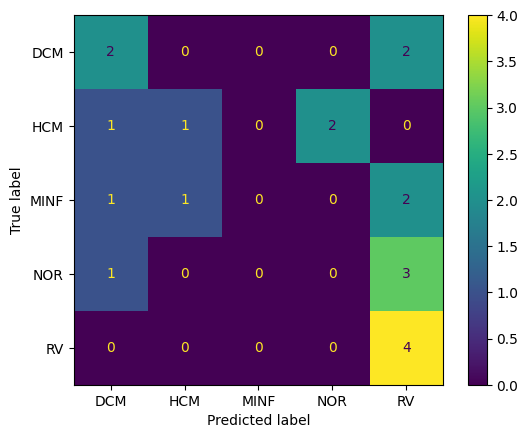

In [16]:
get_metrics(svm, X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

         DCM       0.40      1.00      0.57         4
         HCM       1.00      0.25      0.40         4
        MINF       0.00      0.00      0.00         4
         NOR       0.33      0.75      0.46         4
          RV       0.00      0.00      0.00         4

    accuracy                           0.40        20
   macro avg       0.35      0.40      0.29        20
weighted avg       0.35      0.40      0.29        20

Training accuracy: 0.35
Test accuracy: 0.4


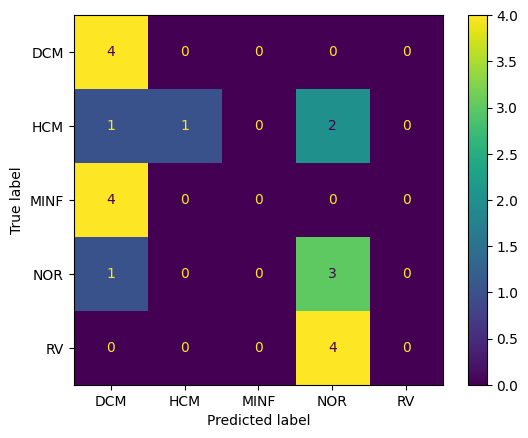

In [17]:
get_metrics(nn, X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

         DCM       0.75      0.75      0.75         4
         HCM       1.00      0.75      0.86         4
        MINF       0.75      0.75      0.75         4
         NOR       0.75      0.75      0.75         4
          RV       0.80      1.00      0.89         4

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20

Training accuracy: 1.0
Test accuracy: 0.8


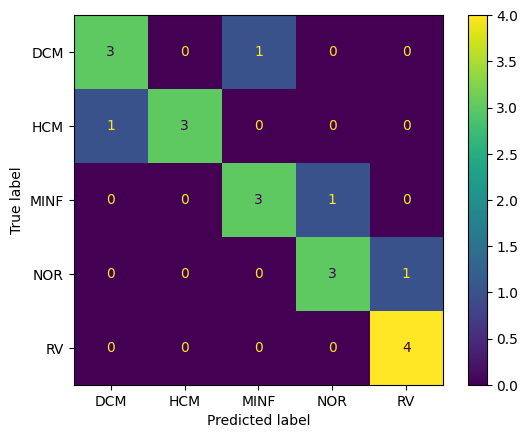

In [18]:
get_metrics(rf, X_train, y_train, X_test, y_test)

### Kfold experiments

In [19]:
# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

# Neural Network
nn = MLPClassifier(random_state=42)
nn.fit(X_train, y_train)

# Random forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
X = df.drop('class', axis=1)
y = df['class']
get_kfold_metrics([svm, nn, rf], X, y)

Model SVC
Test mean accuracy: 0.33, std: 0.117, Train mean accuracy: 0.44, std: 0.069
Model MLPClassifier
Test mean accuracy: 0.49, std: 0.177, Train mean accuracy: 0.57, std: 0.250
Model RandomForestClassifier
Test mean accuracy: 0.76, std: 0.073, Train mean accuracy: 1.0, std: 0.000


After training three different baseline models (SVM, Neural Network, and Random Forest) and validating the predictions using both a simple train-test split and Stratified K-Fold with k = 5 (to maintain the same percentage of class distribution among the folds), it appears that the best-performing model is Random Forest, achieving a mean test accuracy of 76%. However, its 100% accuracy on the training data from the simple train-test split strongly suggests that it suffers from overfitting. Finally, it's worth mentioning that both SVM and Neural Network never predicted any value for the MINF class.

### 4. Feature Engineering and Model Enhancement

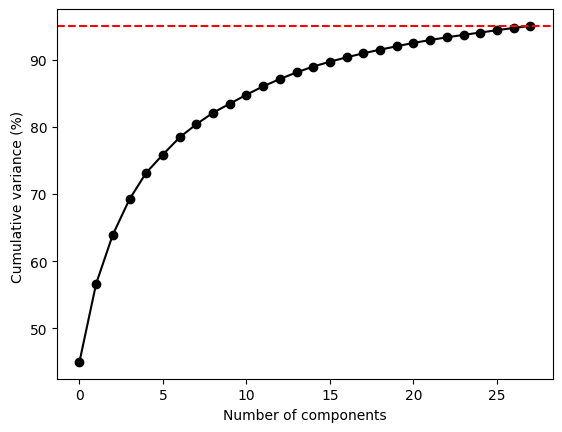

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Define the transform
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_scaled = PCA(n_components=0.95) # we want to capture 95 of the variance
pca_scaled.fit(X_scaled)

# Transform the data
X_scaled_transformed = pca_scaled.transform(X_scaled)
# print("The explained variance for each component is: ", pca_scaled.explained_variance_)
# print("The explained variance ratio per component is: ", pca_scaled.explained_variance_ratio_)
# print("The cumulative variance is: ", pca_scaled.explained_variance_ratio_.cumsum())
# Cumulative plot
plt.plot(100*pca_scaled.explained_variance_ratio_.cumsum(), marker='o', linestyle='-', color='black')
plt.xlabel('Number of components');
plt.ylabel('Cumulative variance (%) ');
plt.axhline(95, color='red', linestyle='--');

### PCA feature engineering + Kfold + supervised methods without hyperparameters finetuning

In [22]:
# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

# Neural Network
nn = MLPClassifier(random_state=42)
nn.fit(X_train, y_train)

# Random forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
X = X_scaled_transformed
y = df['class']
get_kfold_metrics([svm, nn, rf], X, y)

Model SVC
Test mean accuracy: 0.68, std: 0.093, Train mean accuracy: 0.96, std: 0.026
Model MLPClassifier
Test mean accuracy: 0.72, std: 0.040, Train mean accuracy: 1.0, std: 0.000
Model RandomForestClassifier
Test mean accuracy: 0.62, std: 0.068, Train mean accuracy: 1.0, std: 0.000


### LDA feature engineering + Kfold

In [25]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('class',axis=1))
lda = LinearDiscriminantAnalysis()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scores = cross_val_score(lda, X_scaled, y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Mean Accuracy: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))


Mean Accuracy: 0.783 (0.101)


With PCA feature engineering all three models overfit the data, but there is an increasing accuracy in the test set (que significa esto?).

### Hyperparameters finetuning PCA

In [31]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

def hyperparemeters_tuning(df, preprocessing_method="pca", pca_components=0.95):
  X = df.drop('class', axis=1)
  y = df['class']
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

  preprocessing_steps = [
      ('scaler', StandardScaler()),
      ('dim_reduction', PCA(n_components=pca_components, random_state=42))
  ]

  svm_pipeline = Pipeline(preprocessing_steps + [('classifier', SVC(random_state=42))])
  nn_pipeline = Pipeline(preprocessing_steps + [('classifier', MLPClassifier(max_iter=1000, random_state=42))])
  rf_pipeline = Pipeline(preprocessing_steps + [('classifier', RandomForestClassifier(random_state=42))])

  svm_param_grid = {
      'classifier__C': [0.1, 1, 10, 100],
      'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
      'classifier__kernel': ['rbf', 'linear']
  }

  nn_param_grid = {
      'classifier__hidden_layer_sizes': [(50,), (100,), (32, 32)],
      'classifier__activation': ['relu', 'logistic'],
      'classifier__alpha': [0.0001, 0.001, 0.01],
      'classifier__learning_rate': ['constant', 'adaptive']
  }

  rf_param_grid = {
      'classifier__n_estimators': [50, 100, 200],
      'classifier__max_depth': [None, 10, 20],
      'classifier__min_samples_split': [2, 5, 10]
  }

  def tune_classifier(pipeline, param_grid, X, y, cv=cv):
      grid_search = GridSearchCV(
          pipeline,
          param_grid=param_grid,
          cv=cv,
          scoring='accuracy',
          n_jobs=-1,
          verbose=1
      )
      grid_search.fit(X, y)
      print(f"Best parameters: {grid_search.best_params_}")
      print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
      return grid_search.best_estimator_, grid_search.best_score_

  # Tune SVM
  print("Tuning SVM...")
  best_svm, svm_score = tune_classifier(svm_pipeline, svm_param_grid, X, y)

  # Tune Neural Network
  print("\nTuning Neural Network...")
  best_nn, nn_score = tune_classifier(nn_pipeline, nn_param_grid, X, y)

  # Tune Random Forest
  print("\nTuning Random Forest...")
  best_rf, rf_score = tune_classifier(rf_pipeline, rf_param_grid, X, y)

  # Compare the best models
  print("\nBest model comparison:")
  print(f"SVM: {svm_score:.4f}")
  print(f"Neural Network: {nn_score:.4f}")
  print(f"Random Forest: {rf_score:.4f}")

  # Identify the best model
  best_score = max(svm_score, nn_score, rf_score)
  if best_score == svm_score:
      best_model = best_svm
      print("\nBest model: SVM")
  elif best_score == nn_score:
      best_model = best_nn
      print("\nBest model: Neural Network")
  else:
      best_model = best_rf
      print("\nBest model: Random Forest")

  # Final evaluation of the best model using cross-validation
  from sklearn.model_selection import cross_val_predict
  y_pred = cross_val_predict(best_model, X, y, cv=cv)
  accuracy = accuracy_score(y, y_pred)
  print(f"\nFinal cross-validation accuracy: {accuracy:.4f}")
  print(classification_report(y, y_pred))
  return svm_score, nn_score, rf_score

In [ ]:
hyperparemeters_tuning(df, preprocessing_method="pca", pca_components=0.95)

Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best cross-validation score: 0.8200

Tuning Neural Network...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'classifier__activation': 'logistic', 'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate': 'constant'}
Best cross-validation score: 0.8400

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best cross-validation score: 0.7600

Best model comparison:
SVM: 0.8200
Neural Network: 0.8400
Random Forest: 0.7600

Best model: Neural Network

Final cross-validation accuracy: 0.8400
              precision    recall  f1-score   support

         DCM       0.90      0.95      0.93        20
  

### Hyperparameters tunning LDA

In [52]:
# define model
model = LinearDiscriminantAnalysis()
# define model evaluation method
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
# define grid
grid = dict()
grid['solver'] = ['svd', 'lsqr', 'eigen']
grid['shrinkage'] = np.arange(0, 1, 0.01)
# define search
search = GridSearchCV(model, grid, scoring='accuracy', cv=cv, n_jobs=-1)
# perform the search
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('class',axis=1))
results = search.fit(X_scaled, df['class'])
# summarize
print('Mean Accuracy: %.3f' % results.best_score_)
print('Config: %s' % results.best_params_)

Mean Accuracy: 0.873
Config: {'shrinkage': np.float64(0.66), 'solver': 'lsqr'}


In [53]:
results

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=5, random_state=1),
             estimator=LinearDiscriminantAnalysis(), n_jobs=-1,
             param_grid={'shrinkage': array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99]),
                         'solver': ['svd', 'lsqr', 'eigen']},
             scoring='accuracy')

### MRMR

In [30]:
# hyperparameters tunning with all features 647
hyperparemeters_tuning(df)

Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best cross-validation score: 0.8200

Tuning Neural Network...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'classifier__activation': 'logistic', 'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate': 'constant'}
Best cross-validation score: 0.8400

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best cross-validation score: 0.7600

Best model comparison:
SVM: 0.8200
Neural Network: 0.8400
Random Forest: 0.7600

Best model: Neural Network

Final cross-validation accuracy: 0.8400
              precision    recall  f1-score   support

         DCM       0.90      0.95      0.93        20
 

In [ ]:
accs = []

In [35]:
# !pip install mrmr_selection
from mrmr import mrmr_classif
for k in range(120, 240, 10):
  selected_features = mrmr_classif(df.drop('class', axis=1), df['class'], K = k)
  X_train_mrmr = df.loc[:,selected_features]
  X_train_mrmr['class'] = df['class']
  accs.append(hyperparemeters_tuning(X_train_mrmr))


100%|██████████| 120/120 [00:17<00:00,  6.82it/s]


Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best cross-validation score: 0.8500

Tuning Neural Network...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (100,), 'classifier__learning_rate': 'constant'}
Best cross-validation score: 0.8700

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best cross-validation score: 0.8100

Best model comparison:
SVM: 0.8500
Neural Network: 0.8700
Random Forest: 0.8100

Best model: Neural Network

Final cross-validation accuracy: 0.8700
              precision    recall  f1-score   support

         DCM       0.90      0.90      0.90        2

100%|██████████| 130/130 [00:21<00:00,  6.17it/s]


Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best cross-validation score: 0.8600

Tuning Neural Network...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (100,), 'classifier__learning_rate': 'constant'}
Best cross-validation score: 0.8500

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Best cross-validation score: 0.7900

Best model comparison:
SVM: 0.8600
Neural Network: 0.8500
Random Forest: 0.7900

Best model: SVM

Final cross-validation accuracy: 0.8600
              precision    recall  f1-score   support

         DCM       0.86      0.90      0.88        20
         H

100%|██████████| 140/140 [00:27<00:00,  5.13it/s]


...

Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best cross-validation score: 0.8900

Tuning Neural Network...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'classifier__activation': 'logistic', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (32, 32), 'classifier__learning_rate': 'constant'}
Best cross-validation score: 0.8500

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best cross-validation score: 0.8200

Best model comparison:
SVM: 0.8900
Neural Network: 0.8500
Random Forest: 0.8200

Best model: SVM

Final cross-validation accuracy: 0.8900
              precision    recall  f1-score   support

         DCM       0.80      1.00      0.89        20
   

100%|██████████| 220/220 [00:31<00:00,  6.94it/s]


Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best cross-validation score: 0.9000

Tuning Neural Network...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'classifier__activation': 'logistic', 'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (32, 32), 'classifier__learning_rate': 'constant'}
Best cross-validation score: 0.8900

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best cross-validation score: 0.8200

Best model comparison:
SVM: 0.9000
Neural Network: 0.8900
Random Forest: 0.8200

Best model: SVM

Final cross-validation accuracy: 0.9000
              precision    recall  f1-score   support

         DCM       0.83      1.00      0.91        20
     

100%|██████████| 230/230 [00:32<00:00,  7.07it/s]


Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best cross-validation score: 0.9000

Tuning Neural Network...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'classifier__activation': 'logistic', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (100,), 'classifier__learning_rate': 'constant'}
Best cross-validation score: 0.8400

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}
Best cross-validation score: 0.8000

Best model comparison:
SVM: 0.9000
Neural Network: 0.8400
Random Forest: 0.8000

Best model: SVM

Final cross-validation accuracy: 0.9000
              precision    recall  f1-score   support

         DCM       0.87      1.00      0.93        20
     

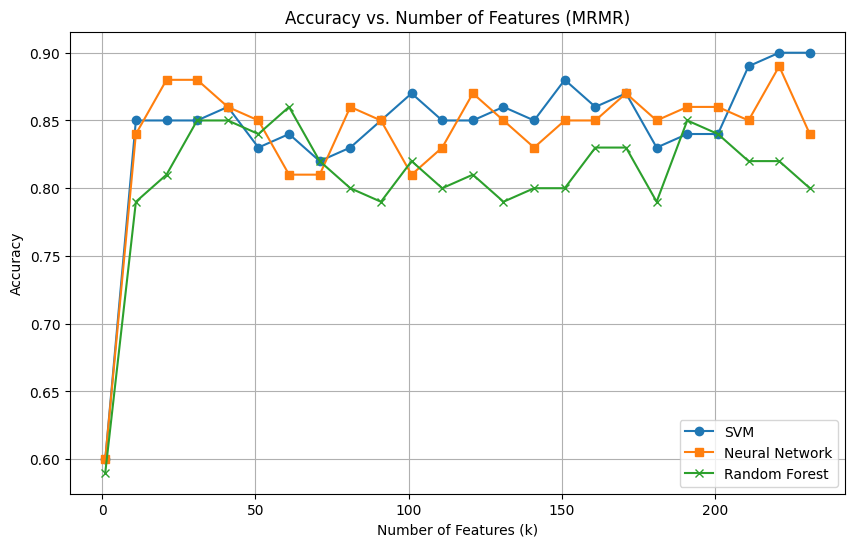

In [42]:
# prompt: plot the accuracies in accs list

import matplotlib.pyplot as plt

# Assuming 'accs' is a list of accuracy scores obtained from hyperparemeters_tuning
# and you want to plot these accuracies against the number of features (k values)

# Create a list of k values corresponding to the accuracies
k_values = list(range(1, 240, 10))

# Assuming accs contains tuples (svm_score, nn_score, rf_score)
svm_scores = [acc[0] for acc in accs]
nn_scores = [acc[1] for acc in accs]
rf_scores = [acc[2] for acc in accs]


plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.plot(k_values, svm_scores, label='SVM', marker='o')
plt.plot(k_values, nn_scores, label='Neural Network', marker='s')
plt.plot(k_values, rf_scores, label='Random Forest', marker='x')


plt.xlabel('Number of Features (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Features (MRMR)')
plt.legend()
plt.grid(True)
plt.show()


### RelieF

In [36]:
!pip install skrebate

  Preparing metadata (setup.py) ... done
  Created wheel for skrebate: filename=skrebate-0.62-py3-none-any.whl size=29253 sha256=45a86c559985c845a27701664416ad3d9299373e4106c6ce0c91490009c61baf
  Stored in directory: /root/.cache/pip/wheels/8a/d2/67/8368fca718041057b33d6448ca526aaf1ce2e404c94b901e41
Successfully built skrebate


In [48]:
from skrebate import ReliefF
accs_relieff = []
# Number of features to retain
for k in range(1, 240, 10):
  n_features = k
  # Define the transform
  reliefFS = ReliefF(n_features_to_select=n_features, n_neighbors=40, n_jobs = -1)
  X_train_relief = reliefFS.fit_transform(df.drop('class',axis=1).values, df['class'])
  df_relief = pd.DataFrame(X_train_relief)
  df_relief['class'] = df['class']
  accs_relieff.append(hyperparemeters_tuning(df_relief))

Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best cross-validation score: 0.6000

Tuning Neural Network...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'classifier__activation': 'logistic', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (32, 32), 'classifier__learning_rate': 'constant'}
Best cross-validation score: 0.6000

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Best cross-validation score: 0.5900

Best model comparison:
SVM: 0.6000
Neural Network: 0.6000
Random Forest: 0.5900

Best model: SVM

Final cross-validation accuracy: 0.6000
              precision    recall  f1-score   support

         DCM       0.86      0.95      0.90        20
        

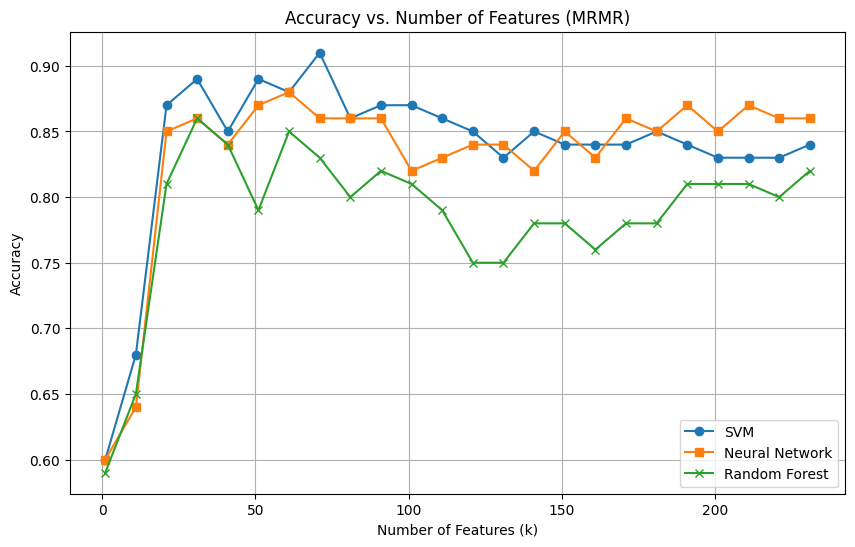

In [49]:
# prompt: plot the accuracies in accs list

import matplotlib.pyplot as plt

# Assuming 'accs' is a list of accuracy scores obtained from hyperparemeters_tuning
# and you want to plot these accuracies against the number of features (k values)

# Create a list of k values corresponding to the accuracies
k_values = list(range(1, 240, 10))

# Assuming accs contains tuples (svm_score, nn_score, rf_score)
svm_scores = [acc[0] for acc in accs_relieff]
nn_scores = [acc[1] for acc in accs_relieff]
rf_scores = [acc[2] for acc in accs_relieff]


plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.plot(k_values, svm_scores, label='SVM', marker='o')
plt.plot(k_values, nn_scores, label='Neural Network', marker='s')
plt.plot(k_values, rf_scores, label='Random Forest', marker='x')


plt.xlabel('Number of Features (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Features (Relieff)')
plt.legend()
plt.grid(True)
plt.show()


#### Quick Analysis:
Linear Discriminant Analysis (LDA) achieved an accuracy of 87.3% after hyperparameter tuning of the solver and shrinkage. Given the original dataset dimensions of 100,647 features and 5 classes, LDA inherently performs feature selection by reducing the number of variables to (n-1 = 4) components.

Principal Component Analysis (PCA) retaining 95% of the variance with 25 components yielded the following best model accuracies:



*   SVM: 0.8200
*   Neural Network: 0.8400
*   Random Forest: 0.7600

#### For MRMR:

SVM generally improves with more features, reaching its best accuracy of around 0.90 with the highest number of features tested ((k=approx 220)).
The Neural Network performs well early on and has multiple peaks in accuracy (around 0.87-0.88), with a final accuracy of about 0.84.
Random Forest peaks earlier with fewer features (accuracy around 0.86 at (k=approx 60)) and then its performance declines with more features, ending at approximately 0.80.


#### For ReliefF:
The plot indicates that for features selected by ReliefF:

SVM achieves the highest peak accuracy (0.91) at a moderate number of features ((k=approx 70)), with generally good performance in the mid-0.80s for a wider range.
The Neural Network shows consistently strong performance (around 0.85-0.88) across a broad range of ReliefF-selected features, peaking at approximately 0.88 around (k=60).
Random Forest reaches its best performance (around 0.86) with a smaller number of ReliefF features ((k=approx 40)), and its accuracy tends to decrease with more features.